<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Laboratorio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot
import pandas as pd


Carga cada archivo en un DataFrame separado. Es el equivalente al np.loadtxt, apila las filas de ambos uno debajo del otro, reiniciando la numeración de las filas desde 0.  En este caso, se usa pd.read_cvs en lugar de np.loadtxt, por el hecho de que el dataset empleado tiene columnas de texto y np.loadtxt solo es para archivos 100% numerico.

In [3]:
ruta = '/content/drive/MyDrive/IA/archive (5)/'
# Leer los dos archivos con datos
df_train = pd.read_csv(ruta + 'train.csv')
df_test  = pd.read_csv(ruta + 'test.csv')

# Unir en un solo DataFrame apilando filas
df = pd.concat([df_train, df_test], ignore_index=True)

print('Filas en train:', len(df_train))
print('Filas en test: ', len(df_test))
print('Total unido:   ', len(df))
print()
print('Columnas disponibles:')
print(df.columns.tolist()) #apilas las filas de los archivos, una debajo de otra

Filas en train: 45593
Filas en test:  11399
Total unido:    56992

Columnas disponibles:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


In [4]:
# Limpiar espacios en nombres de columnas
df.columns = df.columns.str.strip()

# Seleccionar columnas
columnas = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'Time_taken(min)']
df_limpio = df[columnas].copy()

# Limpiar el prefijo "(min) " de la columna objetivo
df_limpio['Time_taken(min)'] = df_limpio['Time_taken(min)'].str.replace('(min) ', '', regex=False)

# Convertir todo a numérico (los que no se puedan convertir quedan como NaN)
df_limpio = df_limpio.apply(pd.to_numeric, errors='coerce')

# Eliminar filas con NaN
df_limpio = df_limpio.dropna()

# Convertir a array NumPy
data = df_limpio.values

# Separar X e y
X = data[:, :3]
y = data[:, 3]
m = y.size

In [5]:
display(X[:5]) #Matriz de x

array([[37. ,  4.9,  2. ],
       [34. ,  4.5,  2. ],
       [23. ,  4.4,  0. ],
       [38. ,  4.7,  0. ],
       [32. ,  4.6,  1. ]])

In [6]:
X.shape

(43685, 3)

Normalizar características: Si no se normaliza, una variable con valores grandes, dominaria a una pequela y el descenso por el gradiente tardaria mucho en converger o directamente, no lo haría

In [7]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [8]:
X_norm, mu, sigma = normalizarCaracteristicas(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)
#mu y sigma se guardan porque se los necesita para normalizar nuevos ejemplos al tiempo de predecir

[[37.   4.9  2. ]
 [34.   4.5  2. ]
 [23.   4.4  0. ]
 ...
 [30.   4.9  1. ]
 [20.   4.7  0. ]
 [23.   4.9  2. ]]
Media calculada: [29.56786082  4.63378047  1.00473847]
Desviación estandar calculada: [5.81436944 0.33471258 0.82095174]
[[ 1.27823649  0.79536756  1.21232648]
 [ 0.7622734  -0.39968762  1.21232648]
 [-1.12959125 -0.69845142 -1.22387033]
 ...
 [ 0.07432262  0.79536756 -0.00577192]
 [-1.64555433  0.19783997 -1.22387033]
 [-1.12959125  0.79536756  1.21232648]]


In [9]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro')
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

In [10]:
def calcularCostoMultiple(X, y, theta):
    m = y.size
    J = 0
    J = (1 / (2 * m)) * np.sum((np.dot(X, theta) - y) ** 2)
    return J

def gradientDescentMultiple(X, y, theta, alpha, num_iters):
    m = y.size
    J_historia = np.zeros(num_iters)

    for i in np.arange(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historia[i] = calcularCostoMultiple(X, y, theta)

    return theta, J_historia

# Agregar columna de unos al inicio de X_norm
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

alpha = 0.1
num_iters = 400
theta = np.zeros(X_ready.shape[1])
theta, J_historia = gradientDescentMultiple(X_ready, y, theta, alpha, num_iters)
print(f'los valores de theta calculados son: {theta}')

los valores de theta calculados son: [26.28902369  2.61392346 -2.92127029 -2.17894315]


In [11]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

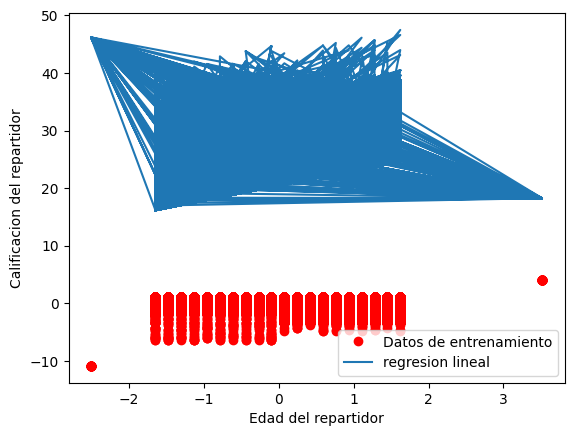

In [12]:
# Etiquetas para los ejes
xlabel1 = 'Edad del repartidor'
xlabel2 = 'Calificacion del repartidor'
xlabel3 = 'Distancia (km)'
ylabel1 = 'Tiempo de entrega (min)'

# Igual que el original: X_ready[:, 1] (Age) en eje X, X_ready[:, 2] (Ratings) en eje Y
graficarDatos(X_ready[:, 1], X_ready[:, 2], xlabel1, xlabel2)
pyplot.plot(X_ready[:, 1], np.dot(X_ready, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

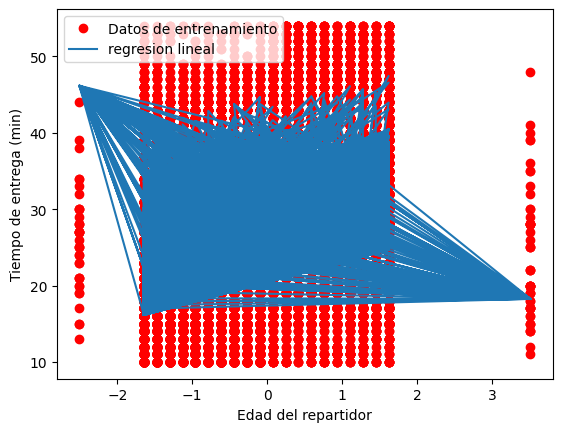

In [13]:
# Gráfica: Age normalizado vs Tiempo de entrega
graficarDatos(X_ready[:, 1], y, xlabel1, ylabel1)
pyplot.plot(X_ready[:, 1], np.dot(X_ready, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

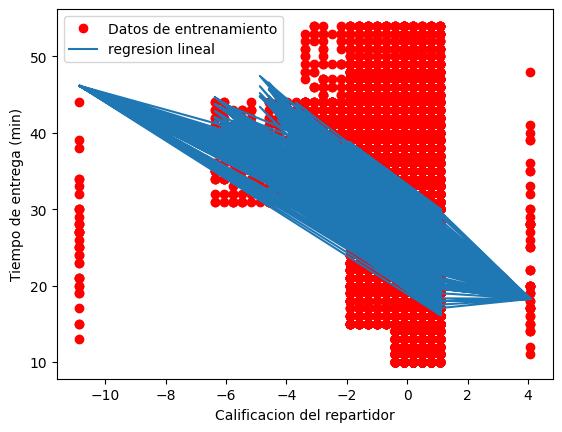

In [14]:
# Gráfica: Ratings normalizado vs Tiempo de entrega
graficarDatos(X_ready[:, 2], y, xlabel2, ylabel1)
pyplot.plot(X_ready[:, 2], np.dot(X_ready, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

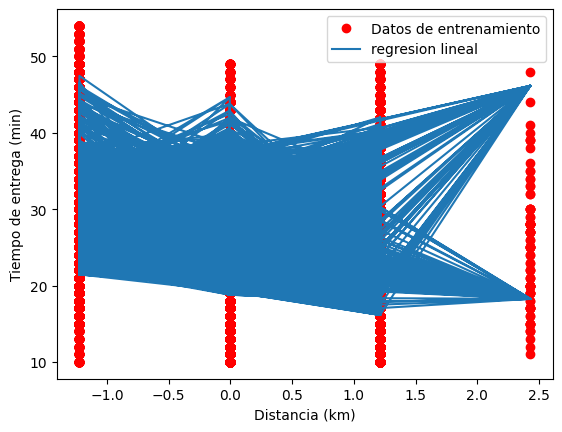

In [15]:
# Gráfica: Distancia normalizada vs Tiempo de entrega
graficarDatos(X_ready[:, 3], y, xlabel3, ylabel1)
pyplot.plot(X_ready[:, 3], np.dot(X_ready, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

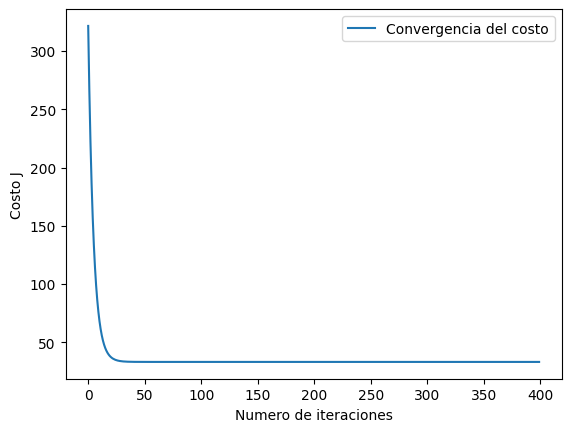

In [16]:
pyplot.figure()
pyplot.plot(np.arange(num_iters), J_historia, '-')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.legend(['Convergencia del costo'])

In [17]:
# Ejemplo: repartidor de 28 años, calificación 4.5, distancia 10 km
nuevo = np.array([28, 4.5, 10])
nuevo_norm = (nuevo - mu) / sigma

y_pred = np.dot([1, nuevo_norm[0], nuevo_norm[1], nuevo_norm[2]], theta)
print(y_pred)

2.8768396785955908


In [18]:
#Utilizando la ecuacion de la normal

In [19]:
def calcularThethaEcuacionNormal(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [20]:
X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)

In [22]:
theta_normal = calcularThethaEcuacionNormal(X_ren, y)
print(f'los valores de theta calculados son: {theta_normal}')

los valores de theta calculados son: [56.10539763  0.44956267 -8.727698   -2.65416718]


Prediccion con ecuacion normal

In [23]:
X_pred_normal = X_ren[:100]
predicciones_normal = np.dot(X_pred_normal, theta_normal)
print('100 predicciones (Ecuación Normal):')
for i, pred in enumerate(predicciones_normal):
    print(f'  Ejemplo {i+1:3d}: {pred:.2f} min  |  Real: {y[i]:.0f} min')

100 predicciones (Ecuación Normal):
  Ejemplo   1: 24.67 min  |  Real: 24 min
  Ejemplo   2: 26.81 min  |  Real: 33 min
  Ejemplo   3: 28.04 min  |  Real: 26 min
  Ejemplo   4: 32.17 min  |  Real: 21 min
  Ejemplo   5: 27.69 min  |  Real: 30 min
  Ejemplo   6: 24.10 min  |  Real: 26 min
  Ejemplo   7: 27.27 min  |  Real: 40 min
  Ejemplo   8: 26.38 min  |  Real: 32 min
  Ejemplo   9: 24.10 min  |  Real: 34 min
  Ejemplo  10: 30.32 min  |  Real: 46 min
  Ejemplo  11: 21.87 min  |  Real: 23 min
  Ejemplo  12: 22.77 min  |  Real: 21 min
  Ejemplo  13: 33.86 min  |  Real: 20 min
  Ejemplo  14: 23.22 min  |  Real: 41 min
  Ejemplo  15: 24.56 min  |  Real: 20 min
  Ejemplo  16: 34.28 min  |  Real: 33 min
  Ejemplo  17: 28.98 min  |  Real: 40 min
  Ejemplo  18: 28.62 min  |  Real: 41 min
  Ejemplo  19: 24.53 min  |  Real: 15 min
  Ejemplo  20: 31.56 min  |  Real: 36 min
  Ejemplo  21: 23.71 min  |  Real: 26 min
  Ejemplo  22: 26.45 min  |  Real: 20 min
  Ejemplo  23: 28.10 min  |  Real: 39 mi

Regresion polinomica:
La regresión polinómica extiende la regresión lineal agregando potencias de las features originales.
Por ejemplo, si tenemos una feature `x`, el modelo polinómico de grado 2 agrega `x²`.
Esto le permite al modelo capturar relaciones curvas entre las variables, no solo líneas rectas.


In [24]:
# X tiene 3 columnas: Age, Ratings, Vehicle_condition
# Agregamos sus cuadrados: Age², Ratings², Vehicle_condition²
def crearFeaturesPolinomicas(X, grado=2):
    X_poly = X.copy()
    for g in range(2, grado + 1):
        X_poly = np.concatenate([X_poly, X ** g], axis=1)
    return X_poly

# Crear X polinómica (grado 2): 3 features originales + 3 cuadradas = 6 features
X_poly = crearFeaturesPolinomicas(X, grado=2)

print('Forma de X original:   ', X.shape)
print('Forma de X polinómica: ', X_poly.shape)
print('Columnas: [Age, Ratings, Veh, Age², Ratings², Veh²]')

Forma de X original:    (43685, 3)
Forma de X polinómica:  (43685, 6)
Columnas: [Age, Ratings, Veh, Age², Ratings², Veh²]


Normalizar caracteristicas polinomicas


In [25]:
X_poly_norm, mu_poly, sigma_poly = normalizarCaracteristicas(X_poly)

print('Media de features polinómicas:              ', mu_poly)
print('Desviación estándar de features polinómicas:', sigma_poly)

Media de features polinómicas:               [ 29.56786082   4.63378047   1.00473847 908.06528557  21.58395399
   1.68346114]
Desviación estándar de features polinómicas: [5.81436944e+00 3.34712577e-01 8.20951735e-01 3.46030836e+02
 2.84796650e+00 1.73111155e+00]


Descenso del gradiente para regresion polinomica

In [26]:
X_ready_poly = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

alpha_poly = 0.1
num_iters_poly = 400
theta_poly = np.zeros(X_ready_poly.shape[1])

theta_poly, J_historia_poly = gradientDescentMultiple(X_ready_poly, y, theta_poly, alpha_poly, num_iters_poly)
print(f'los valores de theta calculados son: {theta_poly}')

los valores de theta calculados son: [26.28902369  1.55700401 -0.91990779 -5.13243741  1.02258875 -1.987125
  3.15403425]


Grafica de convergencia del Costo: Regresion Polinomica

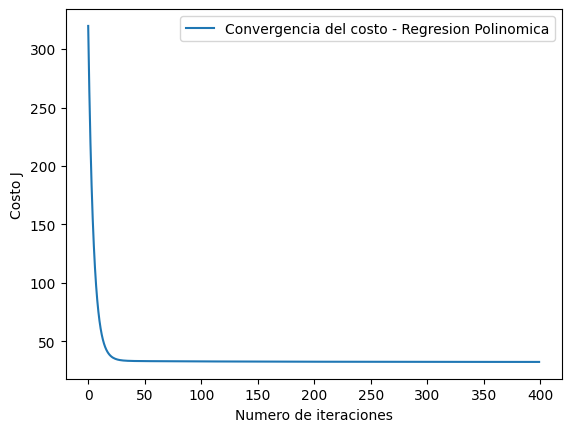

In [27]:
pyplot.figure()
pyplot.plot(np.arange(num_iters_poly), J_historia_poly, '-')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.legend(['Convergencia del costo - Regresion Polinomica'])

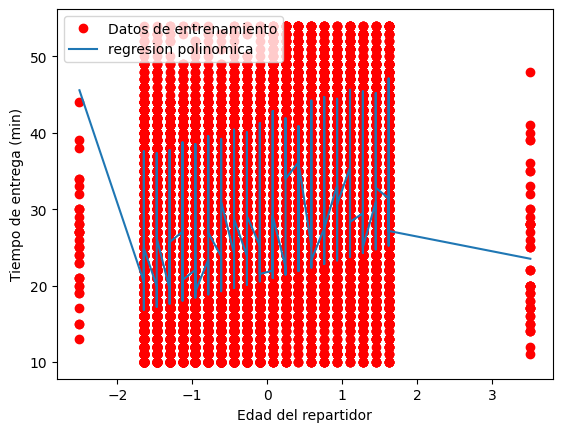

In [28]:
xlabel1 = 'Edad del repartidor'
xlabel2 = 'Calificacion del repartidor'
xlabel3 = 'Condicion del vehiculo'
ylabel1 = 'Tiempo de entrega (min)'

# Gráfica: Age normalizado vs Tiempo de entrega
orden = np.argsort(X_ready_poly[:, 1])
graficarDatos(X_ready_poly[:, 1], y, xlabel1, ylabel1)
pyplot.plot(X_ready_poly[orden, 1], np.dot(X_ready_poly, theta_poly)[orden], '-')
pyplot.legend(['Datos de entrenamiento', 'regresion polinomica'])

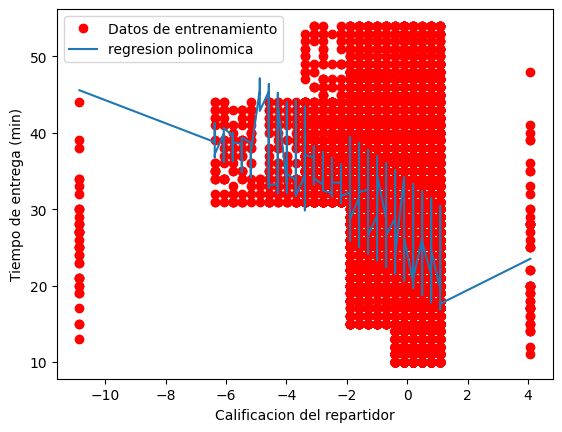

In [29]:
orden = np.argsort(X_ready_poly[:, 2])
graficarDatos(X_ready_poly[:, 2], y, xlabel2, ylabel1)
pyplot.plot(X_ready_poly[orden, 2], np.dot(X_ready_poly, theta_poly)[orden], '-')
pyplot.legend(['Datos de entrenamiento', 'regresion polinomica'])

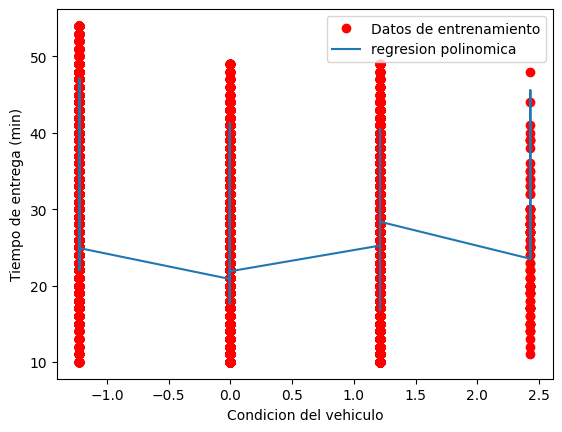

In [30]:
orden = np.argsort(X_ready_poly[:, 3])
graficarDatos(X_ready_poly[:, 3], y, xlabel3, ylabel1)
pyplot.plot(X_ready_poly[orden, 3], np.dot(X_ready_poly, theta_poly)[orden], '-')
pyplot.legend(['Datos de entrenamiento', 'regresion polinomica'])

In [31]:
X_100 = X[:100]  # primeros 100 ejemplos

# Paso 1: crear features polinómicas
X_100_poly = crearFeaturesPolinomicas(X_100, grado=2)

# Paso 2: normalizar con mu_poly y sigma_poly del entrenamiento
X_100_poly_norm = (X_100_poly - mu_poly) / sigma_poly

# Paso 3: agregar bias
X_100_ready = np.concatenate([np.ones((100, 1)), X_100_poly_norm], axis=1)

# Paso 4: predecir
predicciones_poly = np.dot(X_100_ready, theta_poly)

print('100 predicciones (Regresión Polinómica):')
for i, pred in enumerate(predicciones_poly):
    print(f'  Ejemplo {i+1:3d}: {pred:.2f} min  |  Real: {y[i]:.0f} min')

100 predicciones (Regresión Polinómica):
  Ejemplo   1: 25.22 min  |  Real: 24 min
  Ejemplo   2: 27.51 min  |  Real: 33 min
  Ejemplo   3: 28.82 min  |  Real: 26 min
  Ejemplo   4: 32.81 min  |  Real: 21 min
  Ejemplo   5: 26.46 min  |  Real: 30 min
  Ejemplo   6: 24.75 min  |  Real: 26 min
  Ejemplo   7: 25.99 min  |  Real: 40 min
  Ejemplo   8: 27.07 min  |  Real: 32 min
  Ejemplo   9: 24.75 min  |  Real: 34 min
  Ejemplo  10: 31.10 min  |  Real: 46 min
  Ejemplo  11: 20.86 min  |  Real: 23 min
  Ejemplo  12: 21.66 min  |  Real: 21 min
  Ejemplo  13: 34.50 min  |  Real: 20 min
  Ejemplo  14: 22.07 min  |  Real: 41 min
  Ejemplo  15: 25.24 min  |  Real: 20 min
  Ejemplo  16: 33.10 min  |  Real: 33 min
  Ejemplo  17: 29.69 min  |  Real: 40 min
  Ejemplo  18: 29.00 min  |  Real: 41 min
  Ejemplo  19: 25.29 min  |  Real: 15 min
  Ejemplo  20: 32.24 min  |  Real: 36 min
  Ejemplo  21: 24.29 min  |  Real: 26 min
  Ejemplo  22: 25.04 min  |  Real: 20 min
  Ejemplo  23: 28.82 min  |  Real: 


Comparacion de modelos: Se compara los costos de cada modelo, el modelo con el menor costo indica que se ajusta mejor a los datos de entrenamiento.

In [33]:
costo_lineal  = J_historia[-1]
costo_poly    = J_historia_poly[-1]
costo_normal  = calcularCostoMultiple(X_ren, y, theta_normal)

print('-Comparación de costos finales-')
print(f'Regresión Lineal Multivariable: {costo_lineal:.4f}')
print(f'Regresión Polinómica (grado 2): {costo_poly:.4f}')
print(f'Ecuación Normal:                {costo_normal:.4f}')

-Comparación de costos finales-
Regresión Lineal Multivariable: 33.1147
Regresión Polinómica (grado 2): 32.4160
Ecuación Normal:                33.1147
